In [2]:
# replication experiment
%cd /mnt/sdd1/atharvas/formulacode/datasmith
from datasmith.benchmark.collection import BenchmarkCollection

/mnt/sdd1/atharvas/formulacode/datasmith


In [9]:
all_benchmarks_meas1 = BenchmarkCollection.load("artifacts/raw/downloads/sklearn/dashboard.fc.pkl")
all_benchmarks_meas2 = BenchmarkCollection.load(
    "artifacts/benchmark_results/published/html/scikit-learn_scikit-learn/dashboard.fc.pkl"
)

In [3]:
# list(all_benchmarks_meas1.benchmarks.hash.unique())

In [20]:
# all_benchmarks_meas2.benchmarks
all_benchmarks_meas2.summaries["hash"]

0        1519e5b265c4ce087656b260eb08663280bef289
1        5fb9d486e86172a5f2c9453882838047480701c2
2                                             NaN
3        e53407e2db30b59f8cc32269be92f2e08359a189
4                                             NaN
                           ...                   
35760    2ca6d4d2fd53a53f92f8b220edee862553b76ffa
35761                                         NaN
35762    ec1be32e34369c3021569da76a6929497d303301
35763    107e00914692951944e64077398d74b1c5d761c7
35764                                         NaN
Name: hash, Length: 35765, dtype: object

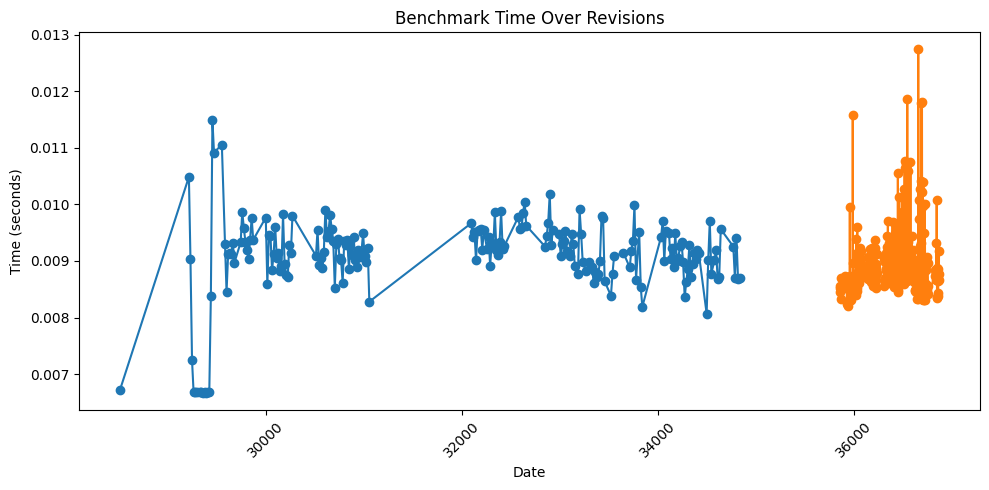

In [ ]:
import matplotlib.pyplot as plt

benchmark_name = "neighbors.KNeighborsClassifierBenchmark.time_fit"
bm1 = all_benchmarks_meas1.summaries.loc[all_benchmarks_meas1.summaries["benchmark"] == benchmark_name].copy()
bm1["sha"] = bm1.revision.astype(str).map(all_benchmarks_meas1.index_data["revision_to_hash"])
bm2 = all_benchmarks_meas2.summaries.loc[all_benchmarks_meas2.summaries["benchmark"] == benchmark_name].copy()
bm2["sha"] = bm2.revision.astype(str).map(all_benchmarks_meas2.index_data["revision_to_hash"])

# plot the revision on the x axis and the time on the y axis
# make it a line plot with markers

plt.figure(figsize=(10, 5))
plt.plot(bm1["revision"], bm1["time"], marker="o", linestyle="-", label="Measurement 1")
plt.plot(bm2["revision"], bm2["time"], marker="o", linestyle="-", label="Measurement 2")
plt.xlabel("Date")
plt.ylabel("Time (seconds)")
plt.title("Benchmark Time Over Revisions")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [6]:
# each hash_info object has a `sha` and a `date`. Plot the
import json

import pandas as pd

all_commits_pth = "artifacts/raw/commits_all.jsonl"
filtered_commits_pth = "artifacts/raw/commits_filtered.jsonl"
with open(all_commits_pth) as fp:
    all_commits = [json.loads(line.strip().replace("'", '"')) for line in fp]

with open(filtered_commits_pth) as fp:
    filtered_commits = [json.loads(line.strip()) for line in fp]

all_commits = pd.DataFrame(all_commits)
filtered_commits = pd.DataFrame(filtered_commits)

In [7]:
all_commits.columns

Index(['idx', 'commit_id', 'repo_name', 'commit_sha'], dtype='object')

In [8]:
filtered_commits.columns

Index(['idx', 'commit_id', 'repo_name', 'commit_sha', 'url', 'is_accessible',
       'is_fork', 'is_archived', 'fork_parent', 'forked_at', 'watchers',
       'stars', 'asv_conf_path', 'sha', 'date', 'message', 'total_additions',
       'total_deletions', 'total_files_changed', 'files_changed'],
      dtype='object')

In [ ]:
# let's make a new jsonl file with just info about these intersection_hashes
from tqdm import tqdm

from datasmith.execution.utils import _get_commit_info, find_file_in_tree

out_path = "artifacts/raw/sklearn_commits_filtered_intersection.jsonl"
repo_name = "scikit-learn/scikit-learn"
asv_conf_path = find_file_in_tree(repo_name, "asv.conf.json")
# main_df = filtered_commits.copy()
main_df = all_commits.copy()

intersection_hashes = set(main_df["commit_sha"]).intersection(set(bm1["sha"]))
subset_commits = main_df[main_df["commit_sha"].isin(intersection_hashes)]

print(f"Number of commits in intersection: {len(intersection_hashes)}")
metadata = []
for sha in tqdm(intersection_hashes):
    commit_info = _get_commit_info(repo_name, sha)
    commit_meta = pd.json_normalize(commit_info)
    # commit_meta has additional info for ONE row of subset_commits
    metadata.append(commit_meta)

metadata = pd.concat(metadata)
# only merge metadata if the columns don't already exist in subset_commits
if not any(col in subset_commits.columns for col in metadata.columns):
    subset_commits = subset_commits.merge(
        metadata, how="left", left_on="commit_sha", right_on="sha", suffixes=("", "_meta")
    )
    subset_commits["asv_conf_path"] = [asv_conf_path] * len(subset_commits)

subset_commits.to_json(out_path, orient="records", lines=True, index=False)

Number of commits in intersection: 35


  0%|          | 0/35 [00:00<?, ?it/s]

100%|██████████| 35/35 [00:00<00:00, 1391.57it/s]


: 

In [ ]:
(list(intersection_hashes))

True